# Cryptocurrency Example - Study 1

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

## Loading the data

In [2]:
df = pd.read_csv('./processed/ageRisk_long.csv', index_col=0)
df['risk-taking'] = df['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})

## Analysis

In [3]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk-taking':'Risk Tendency'}

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
        
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def cohens_d(mean1, mean2, std1, std2, n1, n2):
    diff = mean1 - mean2
    pooled_var = ((n1-1)*std1**2 + (n2-1)*std2**2) / (n1 + n2 - 2)
    d = diff / np.sqrt(pooled_var)
    return d

def reorder_risk_tendency(df):
    order = ['low', 'medium', 'high']
    df['risk-taking'] = pd.Categorical(df['risk-taking'], categories=order, ordered=True)
    df.sort_values(by='risk-taking', inplace=True)
    return df

def show_mean_errplot(raw, column, label, group1, group2=None, isCohen=False):
    show_anova(raw, column, group1, group2)

    if group1 == 'risk-taking' or group2 == 'risk-taking':
        raw = reorder_risk_tendency(raw)
    
    groups = [group1, group2] if group2 != None else [group1]
    grouped = raw.groupby(groups, observed=False)[column]
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()

    standard_errors = std_devs / np.sqrt(sample_sizes)

    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

    if(isCohen):
        # Calculate Cohen's d between 'neutral' and 'averse'
        d_neu_av = cohens_d(means['medium'], means['low'], std_devs['medium'], std_devs['low'], sample_sizes['medium'], sample_sizes['low'])
        print(f"Cohen's d between 'medium' and 'low': {d_neu_av.mean()}")
    
        # Calculate Cohen's d between 'seeking' and 'neutral'
        d_seek_neu = cohens_d(means['high'], means['medium'], std_devs['high'], std_devs['medium'], sample_sizes['high'], sample_sizes['medium'])
        print(f"Cohen's d between 'high' and 'medium': {d_seek_neu.mean()}")

    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), color=colors, zorder=2)
    ax.set_ylabel(label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    group1 = label_dict.get(group1, group1)
    ax.set_xlabel(group1)
    ax.grid(True, zorder=1)
    
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    return means, std_devs

def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight
    
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ais = ['Gemini', 'Copilot', 'ChatGPT']
    ages = [15, 30, 50]
    risk_taking = ['low', 'medium', 'high']
    iterations = list(range(10))
    
    if sep_col:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk-taking', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk-taking', 'iteration', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk-taking', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk-taking', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df


### Example - Cryptocurrencies Portfolio Share

            sum_sq     df          F        PR(>F)
label     2.210862    8.0  45.066079  5.140513e-45
Residual  1.600524  261.0        NaN           NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)  -0.2153    0.0 -0.2786 -0.1521   True
  (ChatGPT, high) (ChatGPT, medium)  -0.1069    0.0 -0.1701 -0.0437   True
  (ChatGPT, high)   (Copilot, high)  -0.1428    0.0 -0.2061 -0.0796   True
  (ChatGPT, high)    (Copilot, low)  -0.2153    0.0 -0.2786 -0.1521   True
  (ChatGPT, high) (Copilot, medium)  -0.2153    0.0 -0.2786 -0.1521   True
  (ChatGPT, high)    (Gemini, high)    0.027 0.9199 -0.0363  0.0902  False
  (ChatGPT, high)     (Gemini, low)  -0.2153    0.0 -0.2786 -0.1521   True
  (ChatGPT, high)  (Gemini, medium)  -0.1894    0.0 -0.2526 -0.1261   True
   (ChatGPT, low) (Cha

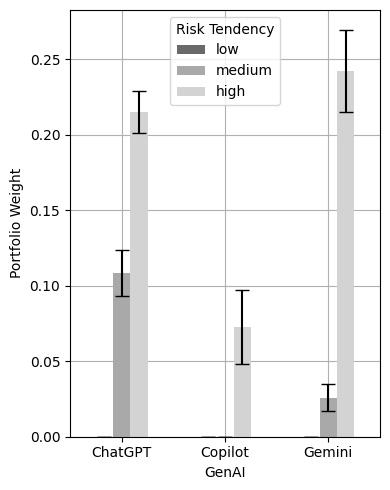

means: risk-taking
low       0.000000
medium    0.044778
high      0.176704
dtype: float64
stds: risk-taking
low       0.000000
medium    0.044194
high      0.119449
dtype: float64


In [5]:
group_cols = ['ai', 'age', 'risk-taking', 'iteration']
df_weighted = df.copy()
df_weighted['weight'] = df_weighted.groupby(group_cols, observed=False)['amount_to_invest'].transform(get_position_weight)
cryptos = df_weighted[df_weighted['asset_type']== 'CRYPTOCURRENCY']
cryptos_grouped = cryptos.groupby(group_cols, observed=False)
crypto_df = cryptos_grouped['weight'].apply(lambda x: x.sum()).reset_index()
crypto_df = prepare_dataframe(crypto_df, 'weight')
means, stds = show_mean_errplot(crypto_df, 'weight', 'Portfolio Weight', 'ai', 'risk-taking', True)
print(f'means: {means.mean()}')
print(f'stds: {stds.mean()}')